In [1]:
!pip install tensorflow scikit-learn shap statsmodels matplotlib pandas numpy

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.8/351.2 MB 10.2 MB/s eta 0:00:35
   ---------------------------------------- 4.2/351.2 MB 10.1 MB/s eta 0:00:35
    --------------------------------------- 6.0/351.2 MB 9.9 MB/s eta 0:00:36
    --------------------------------------- 8.1/351.2 MB 9.9 MB/s eta 0:00:35
   - -------------------------------------- 10.5/351.2 MB 9.9 MB/s eta 0:00:35
   - -------------------------------------- 12.6/351.2 MB 10.0 MB/s eta 0:00:35
   - -------------------------------------- 14.7/351.2 MB 10.0 MB/s eta 0:00:34
   - -------------------------------------- 16.8/351.2 MB 10.0 MB/s eta 0:00:34
   -- ------------------------------------- 18.9/351.2 MB 10.0 MB/s eta 0:00:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:
# =====================================================================
# [Step 0] 환경 설정 및 필수 라이브러리 로드
# =====================================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Input, Dropout
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt
import os
import warnings

# 불필요한 경고문구 숨김
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

In [3]:
# =====================================================================
# [Step 0 & 1] 가상 오염원 시료 데이터 생성 함수 및 환경 설정
# =====================================================================
def generate_virtual_data_advanced(n_samples=5000):
    np.random.seed(2026)
    
    # 1. 기여율 생성 (Dirichlet)
    props = np.random.dirichlet([1, 1, 1, 1, 1], n_samples)
    prop_names = ["p_Manure", "p_Sewage", "p_Fertilizer", "p_Soil", "p_Rain"]
    
    # 2. 오염원별 평균 및 표준편차 설정
    src_mean = np.array([
        [15.0,  5.0, 100.0, 20.0], # Manure
        [10.0,  2.0,  80.0, 10.0], # Sewage
        [-2.0, 15.0,  40.0,  2.0], # Fertilizer
        [5.0,  5.0,  10.0,  5.0],  # Soil
        [-5.0,-10.0,   2.0,  1.0]  # Rain
    ])
    
    src_sd = np.array([
        [2.0, 1.0, 15.0, 3.0],
        [1.5, 0.5, 10.0, 2.0],
        [1.0, 2.0,  5.0, 0.5],
        [1.2, 1.0,  2.0, 1.0],
        [0.5, 2.0,  0.5, 0.2]
    ])
    
    # 3. 혼합 법칙 적용 및 데이터 생성
    M_mean = np.dot(props, src_mean)
    M_var = np.dot(props**2, src_sd**2)
    
    noise = np.random.randn(n_samples, 4)
    features = M_mean + noise * np.sqrt(M_var)
    col_names = ["d15N", "d18O", "Cl", "NO3N"]
    
    df_features = pd.DataFrame(features, columns=col_names)
    df_props = pd.DataFrame(props, columns=prop_names)
    
    # 4. 표준화 수행
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df_features)
    df_features_scaled = pd.DataFrame(features_scaled, columns=col_names)
    
    return df_features, df_features_scaled, df_props, scaler

# 데이터 생성 및 분리
df_raw, df_scaled, df_props, global_scaler = generate_virtual_data_advanced(5000)

X_all = df_scaled.values
Y_all = df_props.values

# 80:20 분리
np.random.seed(2026)
indices = np.random.permutation(len(X_all))
train_size = int(0.8 * len(X_all))

train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, X_test = X_all[train_idx], X_all[test_idx]
Y_train, Y_test = Y_all[train_idx], Y_all[test_idx]

In [ ]:
# =====================================================================
# [Step 1-1] SMOTE 적용을 통한 데이터 불균형 해소 (선택적 프로세스)
# =====================================================================
print("\n=== [Step 1-1. SMOTE 기반 훈련 데이터 불균형 해소 (선택적 적용)] ===")

def apply_smote_regression(X_mat, Y_mat, k_neighbors=5):
    # 1. 각 샘플에서 가장 기여율이 높은 오염원을 지배 오염원(Dominant Source)으로 추출하여 임시 클래스로 지정
    dominant_class = np.argmax(Y_mat, axis=1)
    
    # 2. X(수질/동위원소)와 Y(기여율)를 하나의 행렬로 결합 (동시 보간 목적)
    XY_combined = np.hstack([X_mat, Y_mat])
    
    # 3. SMOTE 알고리즘 적용 (소수 클래스를 K-NN 기반으로 증폭)
    # 특정 지배 오염원의 샘플 수가 너무 적을 경우 k_neighbors를 낮추어야 할 수 있음
    smote = SMOTE(k_neighbors=k_neighbors, random_state=2026)
    XY_resampled, _ = smote.fit_resample(XY_combined, dominant_class)
    
    # 4. 결과에서 다시 X와 Y 분리
    n_x_cols = X_mat.shape[1]
    new_X = XY_resampled[:, :n_x_cols]
    new_Y = XY_resampled[:, n_x_cols:]
    
    # 5. Y(기여율) 값의 총합이 1이 되도록 질량 수지(Mass Balance) 재정규화
    new_Y = np.clip(new_Y, 0, None) # 보간 과정에서 생긴 음수 제거
    pred_sum = np.sum(new_Y, axis=1, keepdims=True)
    new_Y_normalized = np.divide(new_Y, np.where(pred_sum == 0, 1, pred_sum))
    
    return new_X, new_Y_normalized

# SMOTE 함수 테스트 구동 (훈련 데이터에 적용)
X_train_smote, Y_train_smote = apply_smote_regression(X_train, Y_train, k_neighbors=5)

print(f"SMOTE 적용 전 Train 샘플 수: {X_train.shape[0]}")
print(f"SMOTE 적용 후 Train 샘플 수: {X_train_smote.shape[0]}")

# [주의] 실제 모델 학습 시 SMOTE로 증폭된 데이터를 사용하려면 아래의 주석을 해제하세요.
# 현재는 가상 데이터의 양이 충분하므로 기본 데이터(X_train)를 그대로 사용하도록 설정되어 있습니다.
# X_train = X_train_smote
# Y_train = Y_train_smote

In [4]:
# =====================================================================
# [Step 2] AI 모델 3종 (DNN, CNN, LSTM) 구축 및 학습/예측 함수
# =====================================================================
def build_model(method, input_dim, output_dim):
    model = Sequential()
    if method == "DNN":
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))
    elif method == "CNN":
        model.add(Input(shape=(input_dim, 1)))
        model.add(Conv1D(filters=32, kernel_size=2, activation='relu'))
        model.add(Flatten())
        model.add(Dense(32, activation='relu'))
    elif method == "LSTM":
        model.add(Input(shape=(1, input_dim)))
        model.add(LSTM(32, activation='relu'))
        
    # Softmax를 통해 기여율의 합이 1이 되도록 강제
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer='adam', loss='mse')
    return model

def reshape_for_model(method, X):
    if method == "CNN":
        return X.reshape(X.shape[0], X.shape[1], 1)
    elif method == "LSTM":
        return X.reshape(X.shape[0], 1, X.shape[1])
    return X # DNN

def train_and_predict_dl(method, X_tr, Y_tr, X_te, epochs=30, batch_size=32):
    X_tr_reshaped = reshape_for_model(method, X_tr)
    X_te_reshaped = reshape_for_model(method, X_te)
    
    model = build_model(method, input_dim=X_tr.shape[1], output_dim=Y_tr.shape[1])
    model.fit(X_tr_reshaped, Y_tr, epochs=epochs, batch_size=batch_size, verbose=0)
    
    predictions = model.predict(X_te_reshaped, verbose=0)
    return predictions, model

In [5]:
# =====================================================================
# [Step 3] 전체 모델 실행 및 성능 평가
# =====================================================================
def calc_metrics(true, pred):
    epsilon = 1e-10
    mae = np.mean(np.abs(true - pred))
    rmse = np.sqrt(np.mean((true - pred)**2))
    mape = np.mean(np.abs((true - pred) / (true + epsilon))) * 100
    
    numerator = np.sum((true - pred)**2)
    denominator = np.sum((np.abs(pred - np.mean(true)) + np.abs(true - np.mean(true)))**2)
    ioa = 1 - (numerator / (denominator + epsilon))
    return mae, rmse, mape, ioa

ai_methods = ["DNN", "CNN", "LSTM"]
trained_models = {} # SHAP 분석 및 미지시료 분석을 위해 모델 저장

print("\n=== [Step 3. 모델별 성능 평가 (MAE, RMSE, MAPE, IOA)] ===")
for m in ai_methods:
    preds, model = train_and_predict_dl(m, X_train, Y_train, X_test, epochs=50)
    trained_models[m] = model
    mae, rmse, mape, ioa = calc_metrics(Y_test, preds)
    print(f"{m:<12} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | IOA: {ioa:.4f}")


=== [Step 3. 모델별 성능 평가 (MAE, RMSE, MAPE, IOA)] ===
DNN          | MAE: 0.0561 | RMSE: 0.0762 | MAPE: 173.99% | IOA: 0.9345
CNN          | MAE: 0.0559 | RMSE: 0.0760 | MAPE: 176.35% | IOA: 0.9346
LSTM         | MAE: 0.0557 | RMSE: 0.0757 | MAPE: 177.09% | IOA: 0.9350


In [6]:
# =====================================================================
# [Step 3-1] K-fold-crossvalidation 기반 통합 성능 평가
# =====================================================================
print("\n=== [Step 3-1. 5-Fold Cross-Validation 통합 성능 평가] ===")
kf = KFold(n_splits=5, shuffle=True, random_state=2026)

for m in ai_methods:
    fold_metrics = []
    for train_index, test_index in kf.split(X_all):
        X_tr_cv, X_te_cv = X_all[train_index], X_all[test_index]
        Y_tr_cv, Y_te_cv = Y_all[train_index], Y_all[test_index]
        
        cv_preds, _ = train_and_predict_dl(m, X_tr_cv, Y_tr_cv, X_te_cv, epochs=30)
        fold_metrics.append(calc_metrics(Y_te_cv, cv_preds))
        
    avg_metrics = np.mean(fold_metrics, axis=0)
    print(f"[CV] {m:<8} | MAE: {avg_metrics[0]:.4f} | RMSE: {avg_metrics[1]:.4f} | MAPE: {avg_metrics[2]:.2f}% | IOA: {avg_metrics[3]:.4f}")


=== [Step 3-1. 5-Fold Cross-Validation 통합 성능 평가] ===
[CV] DNN      | MAE: 0.0564 | RMSE: 0.0776 | MAPE: 297.93% | IOA: 0.9333
[CV] CNN      | MAE: 0.0562 | RMSE: 0.0773 | MAPE: 294.94% | IOA: 0.9338
[CV] LSTM     | MAE: 0.0561 | RMSE: 0.0770 | MAPE: 289.72% | IOA: 0.9338


In [7]:
# =====================================================================
# [Step 4] 미지 시료 분석 프로세스
# =====================================================================
# ---------------------------------------------------------------------
# [Step 4-1] 임의의 단일 시료(Single Sample) 예측
# ---------------------------------------------------------------------
print("\n=== [4-1. 단일 임의 시료 기반 알고리즘별 추정 결과] ===")
single_matrix = np.array([[12.5, 3.2, 90, 15]])
single_matrix_scaled = global_scaler.transform(single_matrix)

for m in ai_methods:
    X_single = reshape_for_model(m, single_matrix_scaled)
    single_pred = trained_models[m].predict(X_single, verbose=0)
    print(f"[{m}]: {np.round(single_pred[0], 4)}")


=== [4-1. 단일 임의 시료 기반 알고리즘별 추정 결과] ===
[DNN]: [0.6345 0.2232 0.0336 0.0524 0.0564]
[CNN]: [0.6344 0.2398 0.0298 0.0476 0.0484]
[LSTM]: [0.6289 0.2392 0.0348 0.0499 0.0473]


In [8]:
# ---------------------------------------------------------------------
# [Step 4-2] CSV 파일을 이용한 대량(Batch) 예측 및 병합 저장 프로세스
# ---------------------------------------------------------------------
cat_header_42 = "\n=== [4-2. CSV 미지 시료 배치 분석 및 모델별 결과 저장] ==="
csv_path = "C:/Users/User/Desktop/sample data 1_HSY.csv"

if os.path.exists(csv_path):
    print(cat_header_42)
    # 1. 독립적으로 데이터 로드
    unknown_samples_df = pd.read_csv(csv_path)
    
    # 2. 분석용 행렬 추출 및 표준화 (학습 시 사용한 global_scaler 적용)
    unknown_matrix = unknown_samples_df[["d15N", "d18O", "Cl", "NO3N"]].values
    unknown_matrix_scaled = global_scaler.transform(unknown_matrix)
    
    for m in ai_methods:
        # 모델별 입력 형상 조정 및 예측
        X_batch = reshape_for_model(m, unknown_matrix_scaled)
        batch_preds = trained_models[m].predict(X_batch, verbose=0)
        
        # 예측 결과를 데이터프레임으로 변환 (컬럼명은 df_props 기준)
        pred_df = pd.DataFrame(batch_preds, columns=df_props.columns)
        
        # 원본 데이터와 병합 및 저장
        final_output = pd.concat([unknown_samples_df, pred_df.round(4)], axis=1)
        output_filename = f"Final_Contribution_{m}.csv"
        final_output.to_csv(output_filename, index=False)
        print(f"[{m}] 배치 분석 및 파일 저장 완료: {output_filename}")
        
    print("Step 4-2 프로세스가 성공적으로 완료되었습니다.")
else:
    print(f"\n[알림] '{csv_path}' 파일이 없어 4-2 단계를 건너뜁니다.")


=== [4-2. CSV 미지 시료 배치 분석 및 모델별 결과 저장] ===
[DNN] 배치 분석 및 파일 저장 완료: Final_Contribution_DNN.csv
[CNN] 배치 분석 및 파일 저장 완료: Final_Contribution_CNN.csv
[LSTM] 배치 분석 및 파일 저장 완료: Final_Contribution_LSTM.csv
Step 4-2 프로세스가 성공적으로 완료되었습니다.


In [9]:
# ---------------------------------------------------------------------
# [Step 4-3] 고정(임의)효과 기반 오염원 기여율 패턴 분석 및 저장
# ---------------------------------------------------------------------
cat_header_43 = "\n=== [4-3. 고정/임의효과(그룹별) 오염원 기여율 패턴 분석] ==="
target_file = "C:/Users/User/Desktop/sample data 1_HSY.csv"

if os.path.exists(target_file):
    print(cat_header_43)
    # 1. 독립적으로 데이터 로드 (4-2와 별개로 다시 읽음)
    sample_df = pd.read_csv(target_file)
    
    # 2. 분석용 행렬 추출 및 표준화
    sample_matrix = sample_df[["d15N", "d18O", "Cl", "NO3N"]].values
    sample_matrix_scaled = global_scaler.transform(sample_matrix)
    
    target_effects = ["month", "spot"]
    
    for m in ai_methods:
        # 패턴 분석을 위한 예측 수행
        X_effect = reshape_for_model(m, sample_matrix_scaled)
        effect_preds = trained_models[m].predict(X_effect, verbose=0)
        
        # 예측 결과 병합
        pred_df_effect = pd.DataFrame(effect_preds, columns=df_props.columns)
        effect_output = pd.concat([sample_df, pred_df_effect.round(4)], axis=1)
        
        # 설정된 고정(임의)효과별 그룹 통계 산출
        for effect in target_effects:
            if effect in effect_output.columns:
                # 그룹별 평균(mean) 및 표준편차(std) 계산
                summary_df = effect_output.groupby(effect)[df_props.columns].agg(['mean', 'std']).reset_index()
                
                # 컬럼명 정리 (R의 .names = "{.col}_{.fn}" 논리 적용)
                summary_df.columns = [effect] + [f"{col}_{stat}" for col, stat in summary_df.columns[1:]]
                
                # 결과 저장
                summary_filename = f"Summary_Contribution_{m}_by_{effect}.csv"
                summary_df.round(4).to_csv(summary_filename, index=False)
                print(f"[{m}] {effect}별 그룹 통계 파일 저장 완료: {summary_filename}")
                
    print("Step 4-3 고정/임의효과 분석이 모두 완료되었습니다.")
else:
    print(f"\n[알림] '{target_file}' 파일이 없어 4-3 단계를 건너뜁니다.")


=== [4-3. 고정/임의효과(그룹별) 오염원 기여율 패턴 분석] ===
[DNN] month별 그룹 통계 파일 저장 완료: Summary_Contribution_DNN_by_month.csv
[DNN] spot별 그룹 통계 파일 저장 완료: Summary_Contribution_DNN_by_spot.csv
[CNN] month별 그룹 통계 파일 저장 완료: Summary_Contribution_CNN_by_month.csv
[CNN] spot별 그룹 통계 파일 저장 완료: Summary_Contribution_CNN_by_spot.csv
[LSTM] month별 그룹 통계 파일 저장 완료: Summary_Contribution_LSTM_by_month.csv
[LSTM] spot별 그룹 통계 파일 저장 완료: Summary_Contribution_LSTM_by_spot.csv
Step 4-3 고정/임의효과 분석이 모두 완료되었습니다.



=== [5. 모든 모델 및 오염원에 대한 통합 XAI 분석 시작] ===
SHAP 중요도 산출 및 시각화(PNG 저장)가 완료되었습니다.


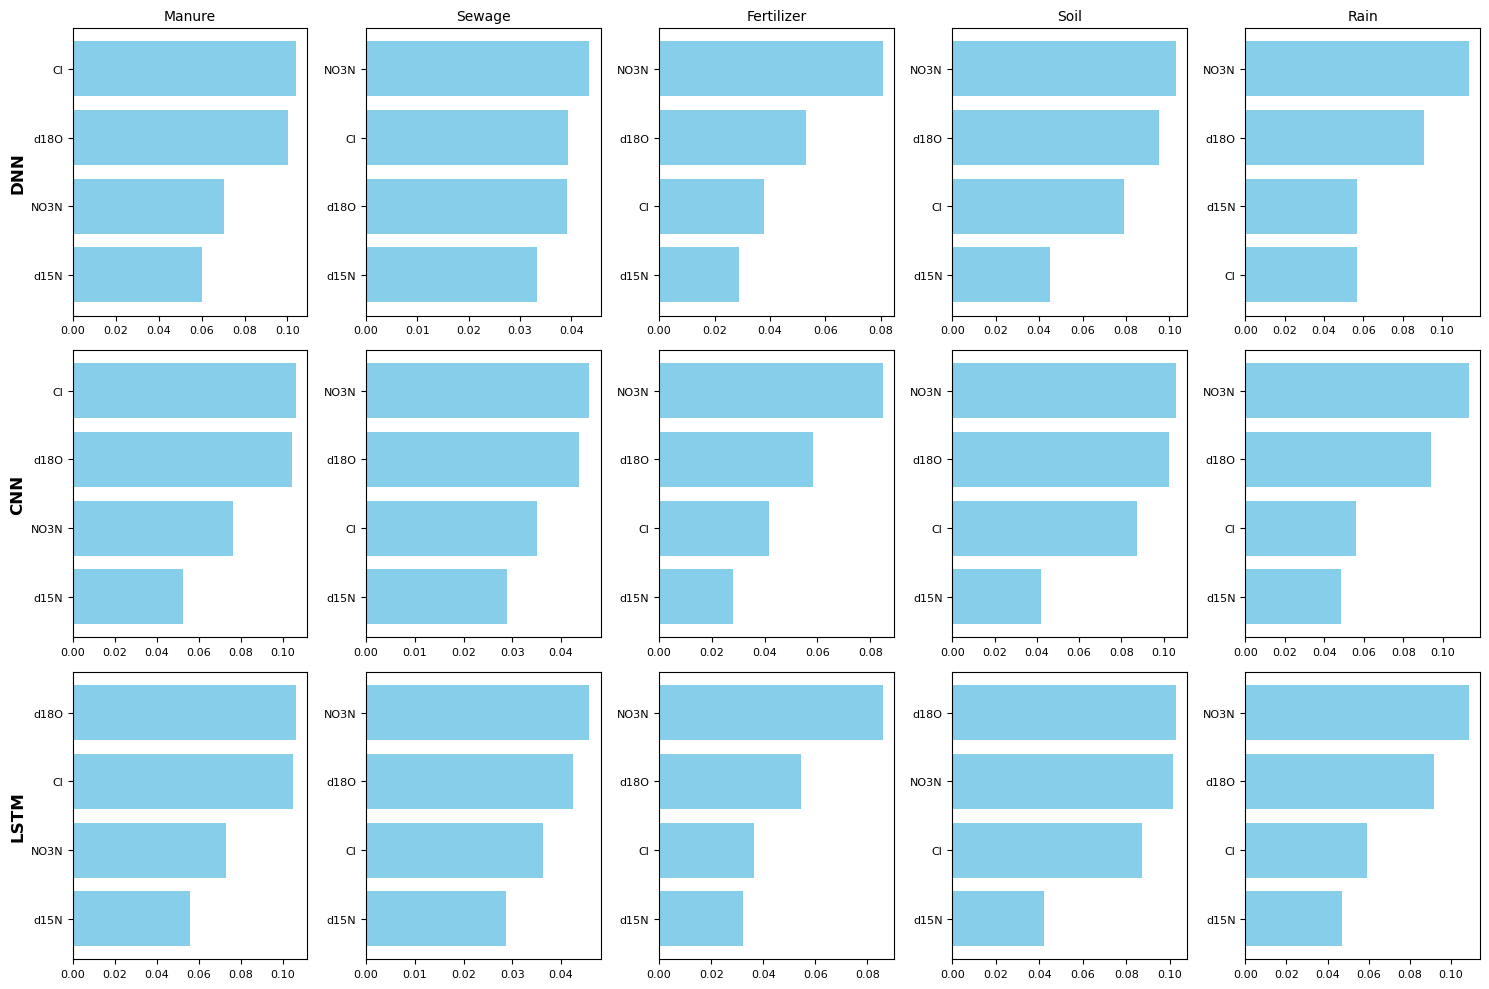

In [10]:
# =====================================================================
# [Step 5] 통합 XAI (SHAP) 분석 (KernelExplainer 활용)
# =====================================================================
print("\n=== [5. 모든 모델 및 오염원에 대한 통합 XAI 분석 시작] ===")
X_explain_raw = X_all[:50] # SHAP 계산을 위한 백그라운드 데이터 (속도를 위해 50개 제한)

all_shap_results = []
feature_names = ["d15N", "d18O", "Cl", "NO3N"]
source_names = df_props.columns

for m in ai_methods:
    model = trained_models[m]
    
    # SHAP는 2D 입력을 기본으로 받도록 래핑하여 차원 문제 우회
    def predict_wrapper(x):
        x_reshaped = reshape_for_model(m, x)
        return model.predict(x_reshaped, verbose=0)
    
    explainer = shap.KernelExplainer(predict_wrapper, X_explain_raw[:10])
    shap_values = explainer.shap_values(X_explain_raw, silent=True)
    
    # shap_values의 형태: (샘플수, 피처수)의 배열이 타겟 수(5)만큼 리스트로 묶여있음
    for s_idx, s_name in enumerate(source_names):
        imp_scores = np.mean(np.abs(shap_values[s_idx]), axis=0)
        for f_idx, f_name in enumerate(feature_names):
            all_shap_results.append({
                "Method": m,
                "Source": s_name,
                "Feature": f_name,
                "Importance": imp_scores[f_idx]
            })

shap_df = pd.DataFrame(all_shap_results)

if len(shap_df) > 0:
    shap_df.to_csv("Total_XAI_Importance_Results_Fixed.csv", index=False)
    
    # 시각화 수행
    plt.figure(figsize=(15, 10))
    for i, m in enumerate(ai_methods):
        for j, s in enumerate(source_names):
            ax = plt.subplot(len(ai_methods), len(source_names), i * len(source_names) + j + 1)
            subset = shap_df[(shap_df['Method'] == m) & (shap_df['Source'] == s)]
            subset = subset.sort_values(by="Importance")
            
            ax.barh(subset['Feature'], subset['Importance'], color='skyblue')
            if i == 0:
                ax.set_title(s.replace('p_', ''), fontsize=10)
            if j == 0:
                ax.set_ylabel(m, fontsize=12, fontweight='bold')
            ax.tick_params(axis='both', which='major', labelsize=8)

    plt.tight_layout()
    # 논문 컴파일 속도를 고려하여 PNG 형식으로 저장
    plt.savefig("Total_XAI_Importance_Results.png", format='png', dpi=150)
    print("SHAP 중요도 산출 및 시각화(PNG 저장)가 완료되었습니다.")